In [4]:
import tensorflow as tf 
from tensorflow.keras.datasets import imdb 
from tensorflow.keras.preprocessing.sequence import pad_sequences 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense 
import matplotlib.pyplot as plt

In [6]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train)) 
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [7]:
max_len = 200

x_train = pad_sequences(x_train, maxlen=max_len) 
x_test = pad_sequences(x_test, maxlen=max_len) 

print("Shape after padding:", x_train.shape)

Shape after padding: (25000, 200)


In [8]:
model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    SimpleRNN(64), 
    Dense(1, activation='sigmoid')
]) 

model.summary()

C:\Users\Eynir\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile( 
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy'] 
)

In [10]:
history = model.fit( 
    x_train, y_train, 
    epochs=5, 
    batch_size=64, 
    validation_split=0.2 
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.6170 - loss: 0.6430 - val_accuracy: 0.6550 - val_loss: 0.6085
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8217 - loss: 0.4001 - val_accuracy: 0.8076 - val_loss: 0.4538
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8857 - loss: 0.2750 - val_accuracy: 0.7950 - val_loss: 0.5085
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9686 - loss: 0.0931 - val_accuracy: 0.7974 - val_loss: 0.5896
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9902 - loss: 0.0349 - val_accuracy: 0.7768 - val_loss: 0.7543


In [11]:
loss, accuracy = model.evaluate(x_test, y_test) 
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7754 - loss: 0.7667 
Test Accuracy: 0.7753999829292297


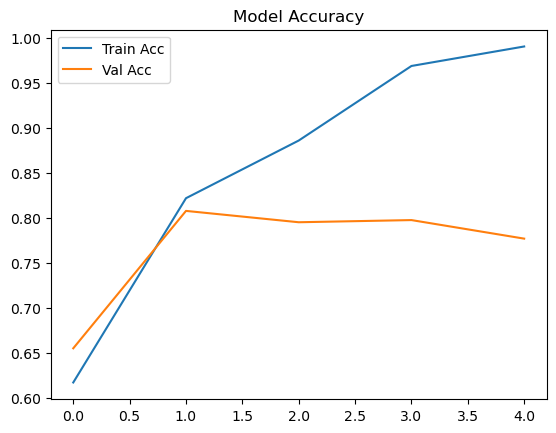

In [12]:
plt.plot(history.history['accuracy'], label='Train Acc') 
plt.plot(history.history['val_accuracy'], label='Val Acc') 
plt.legend() 
plt.title("Model Accuracy") 
plt.show()

In [ ]:
from tensorflow.keras.datasets import imdb 
from tensorflow.keras.preprocessing.text import Tokenizer

word_index = imdb.get_word_index() 
word_index = {k: (v + 3) for k, v in word_index.items()} 
word_index["<PAD>"] = 0 
word_index["<START>"] = 1 
word_index["<UNK>"] = 2 
word_index["<UNUSED>"] = 3 

tokenizer = Tokenizer(num_words=vocab_size) 
tokenizer.word_index = word_index

In [ ]:
user_review = input("Type your movie review: ").lower() 

sequence = tokenizer.texts_to_sequences([user_review]) 
padded = pad_sequences(sequence, maxlen=max_len) 

prediction = model.predict(padded, verbose=0) 

sentiment = "Positive ￿" if prediction[0][0] > 0.5 else "Negative ￿" 

print("\nProbability:", prediction[0][0]) 
print("Sentiment:", sentiment)